In [29]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
x,y=load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)
from sklearn.linear_model import Ridge
reg=Ridge(alpha=0.0975,solver='cholesky')
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print("reg.coef_",reg.coef_)
print("reg.intercept_",reg.intercept_)
print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

reg.coef_ [  43.95716326 -242.66054464  453.90854929  332.76015185  -78.08195327
  -67.90588739 -164.50913675  150.25816147  433.10822181   58.03577672]
reg.intercept_ 150.888902767397
R2 Score: 0.46934122521595056
MAE: 42.51867711332909
MSE: 2894.4016125276266
RMSE: 53.799643237921444


In [2]:
class myridge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None

    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])
        I[0][0]=0 # since we do not penalize intercept and penalize only coefficients
        betas=np.linalg.inv(np.dot(x_train.T,x_train)+self.alpha*I).dot(x_train.T).dot(y_train)
        self.coef_=betas[1:]
        self.intercept_=betas[0]
        pass

    def predict(self,x_test):
        return np.dot(x_test,self.coef_)+self.intercept_

In [3]:
mr=myridge()
mr.fit(x_train,y_train)
y_pred=mr.predict(x_test)
print(mr.coef_,mr.intercept_)
print("r2_score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681] 150.8905342560281
r2_score: 0.46931288533098026
MAE: 42.513836411841076
MSE: 2894.556188335386
RMSE: 53.8010798064071


[27.82809103] -2.29474455867698
[27.51161826] -2.2762602094050255
[27.51130507] -2.276241917183367
[24.9546267] -2.1269130035235735
[12.93442104] -1.4248441496033308


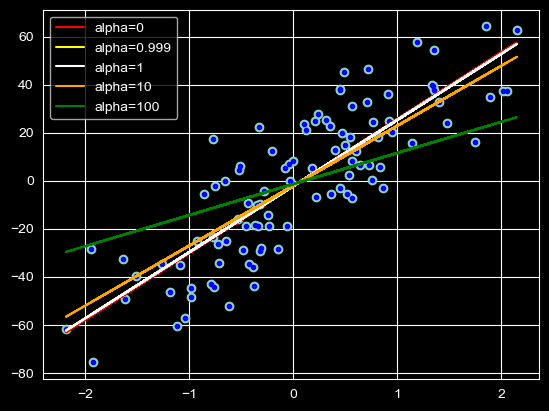

In [4]:
from sklearn.datasets import make_regression
from matplotlib import pyplot as plt
import numpy as np
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
plt.scatter(x,y)
#plt.show()
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
print(lr.coef_,lr.intercept_)
rr=Ridge(alpha=0.999)
rr.fit(x,y)
print(rr.coef_,rr.intercept_)
rr1=Ridge(alpha=1)
rr1.fit(x,y)
print(rr1.coef_,rr1.intercept_)
rr_10=Ridge(alpha=10)
rr_10.fit(x,y)
print(rr_10.coef_,rr_10.intercept_)
rr_100=Ridge(alpha=100)
rr_100.fit(x,y)
print(rr_100.coef_,rr_100.intercept_)
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),'red',label='alpha=0')
plt.plot(x,rr.predict(x),'yellow',label='alpha=0.999')
plt.plot(x,rr1.predict(x),'white',label='alpha=1')
plt.plot(x,rr_10.predict(x),'orange',label='alpha=10')
plt.plot(x,rr_100.predict(x),'green',label='alpha=100')
plt.legend()
#print("r2_score:",r2_score(y,y_pred))
#print("MAE:",mean_absolute_error(y,y_pred))
#print("MSE:",mean_squared_error(y,y_pred))
#print("RMSE:", np.sqrt(mean_squared_error(y,y_pred)))

In [5]:
#Ridge regression using SGDRegressor. This offers option to tune both learning rate and lambda
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, Ridge
x, y = load_diabetes(return_X_y=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)
sgdr=SGDRegressor(penalty='l2',max_iter=150,learning_rate='constant',eta0=0.1,alpha=0.001)
sgdr.fit(x_train,y_train)
y_pred=sgdr.predict(x_test)
print("R2 Score:",r2_score(y_test,y_pred))
print(sgdr.coef_,sgdr.intercept_)
rr=Ridge(alpha=0.1,max_iter=50,solver='sparse_cg')
rr.fit(x_train,y_train)
ry_pred=rr.predict(x_test)
print("R2 Score:",r2_score(y_test,ry_pred))
print(rr.coef_,rr.intercept_)

R2 Score: 0.40934175970646114
[ 5.14191800e+01 -1.40054074e+02  3.54826702e+02  2.63951534e+02
  1.72147245e-01 -5.16763949e+01 -1.67143761e+02  1.39085443e+02
  3.17047141e+02  1.07983739e+02] [140.10988296]
R2 Score: 0.4693131422379794
[  44.02298036 -241.68258308  453.02131631  332.03967633  -76.33710328
  -68.5477202  -164.9411013   150.03480157  431.57882894   58.50613138] 150.89056937059104


In [6]:
import numpy as np
class RidgeGD:
    def __init__(self,epochs,alpha=0.1,learn_rate=0.1):
        self.coef_=None
        self.intercept_=None
        self.alpha=alpha
        self.learn_rate=learn_rate
        self.epochs=epochs

    def fit(self,x_train,y_train):
        self.coef_=np.ones(x_train.shape[1])
        self.intercept_ = 0
        beta=np.insert(self.coef_,0,self.intercept_)
        x_train=np.insert(x_train,0,1,axis=1)

        for i in range(self.epochs):
            dbeta=np.dot(x_train.T,x_train).dot(beta) - np.dot(x_train.T,y_train) + self.alpha*beta
            beta -= self.learn_rate*dbeta

        self.coef_=beta[1:]
        self.intercept_=beta[0]

    def predict(self,x_test):
        return np.dot(x_test,self.coef_) + self.intercept_

In [7]:
rgd=RidgeGD(epochs=500,alpha=0.005,learn_rate=0.005)
rgd.fit(x_train,y_train)
y_hat=rgd.predict(x_test)
print("r2_score:",r2_score(y_test,y_hat))
print("coef_:",rgd.coef_)
print("intercept_:",rgd.intercept_)

r2_score: 0.4736718493543183
coef_: [  46.70820294 -220.35701043  450.90858754  324.73064823  -28.71480294
  -95.89280611 -190.59360482  146.23342202  399.77989463   95.2056005 ]
intercept_: 150.87108809544367


Experiments and studying the impacts of increasing Lambda


In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load data
X, y = load_diabetes(return_X_y=True)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)
alphas = [0.01, 0.1, 1, 10, 100,500,1000,5000,10000]

results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X, y)

    y_pred = model.predict(X)

    rss = np.sum((y - y_pred)**2)
    norm_beta_sq = np.sum(model.coef_**2)

    results.append({
        "alpha": alpha,
        "RSS": rss,
        "||beta||^2": norm_beta_sq,
        "Total Loss": rss + alpha * norm_beta_sq
    })

df = pd.DataFrame(results)
print(df)

      alpha           RSS   ||beta||^2    Total Loss
0      0.01  1.263986e+06  4281.290942  1.264029e+06
1      0.10  1.263992e+06  4161.517116  1.264409e+06
2      1.00  1.264422e+06  3309.321171  1.267731e+06
3     10.00  1.269514e+06  1812.085874  1.287634e+06
4    100.00  1.294304e+06  1207.724550  1.415077e+06
5    500.00  1.461843e+06   542.146394  1.732916e+06
6   1000.00  1.632517e+06   301.191285  1.933709e+06
7   5000.00  2.164652e+06    39.660763  2.362956e+06
8  10000.00  2.348338e+06    12.655573  2.474894e+06


In [9]:
model = Ridge(alpha=0.01).fit(X, y)
print("RSS:", np.sum((y - model.predict(X))**2))
print("||beta||^2:", np.sum(model.coef_**2))

RSS: 1263985.854720469
||beta||^2: 4281.2909423980545


In [10]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X, y)

print("Best alpha:", model.alpha_)

Best alpha: 0.1


In [11]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Load and standardize
X, y = load_diabetes(return_X_y=True)
X = X[:, :2]  # 2 features for clarity
X = StandardScaler().fit_transform(X)

# Pick a lambda
alpha = 1

# Fit ridge
model = Ridge(alpha=alpha)
model.fit(X, y)
beta = model.coef_

# Compute gradients
residual = y - X @ beta

grad_rss = -2 * X.T @ residual
grad_penalty = 2 * beta

# Compare both sides
lhs = grad_rss
rhs = alpha * grad_penalty

print("Gradient RSS:", lhs)
print("Lambda * Gradient Penalty:", rhs)
print("\nDifference:", lhs - rhs)

Gradient RSS: [-28.58356244  -1.66225659]
Lambda * Gradient Penalty: [28.58356244  1.66225659]

Difference: [-57.16712489  -3.32451319]


Key Learnings

In [1]:
#How the coefficients get affected as we increase Lambda. Coefficients get closer to zero but not exactly equal to zero.
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = load_diabetes()
x_train,x_test,y_train,y_test=train_test_split(data.data,data.target,test_size=0.2,random_state=2)
coefs=[]
r2_scores=[]
for i in [0,10,100,1000]:
    reg=Ridge(alpha=i).fit(x_train,y_train)
    coefs.append(reg.coef_.tolist())
    y_hat=reg.predict(x_test)
    r2_scores.append(r2_score(y_test,y_hat))